<a href="https://colab.research.google.com/github/weagan/In-Context-Learning/blob/main/lora_vs_icl_indirect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoRA Fine-tuning vs. In-Context Learning — Indirect Food Inference

This notebook compares two adaptation strategies for **GPT-2** on a task that
requires **inference**, not retrieval:

| Method | Description |
|--------|-------------|
| **Generative ICL** | Frozen GPT-2 + few-shot prompt; no weight updates |
| **LoRA Fine-tuned GPT-2** | GPT-2 with LoRA adapters trained on task data |

## Why indirect inference?

A common pitfall in ICL vs. LoRA comparisons is making the task too easy.
If the label word appears verbatim in the context (e.g. *"People in Rome love
**pizza**"*), a frozen model can score 100% by copying — there is nothing
to learn.

Here, every context describes food **indirectly** through clues:

> *"Alice asked for extra soy sauce on the side."* → **sushi**  
> *"Bob requested no cheese, thin crust."* → **pizza**  
> *"Charlie always adds jalapeños and asks for a tortilla."* → **tacos**  
> *"Diana chose penne and asked for it al dente."* → **pasta**

The food label **never appears** in the context string. A frozen GPT-2 must
rely on world-knowledge associations baked in during pre-training, which it
mostly lacks for these specific clues. LoRA fine-tuning learns the mapping
explicitly, producing a clear accuracy gap.

## Mathematical Formulation of GPT-2's Core Components

GPT-2 is built upon the **Transformer** architecture. Here's a breakdown of its key mathematical components:

### General Notation:
- $N$: Batch size
- $L$: Sequence length (number of tokens in input)
- $d_{\text{model}}$: Dimensionality of the model (embedding size, e.g., 768 for GPT-2 base)
- $V$: Vocabulary size
- $h$: Number of attention heads
- $d_k = d_v = d_{\text{model}} / h$: Dimension of Query/Key/Value vectors per head
- $d_{\text{ff}}$: Inner dimension of the feed-forward network (typically $4 \times d_{\text{model}}$)

### 1. Input Embedding

Each token (word or subword) in the input sequence is converted into a vector representation. This involves a combination of token embeddings and positional embeddings (though GPT-2 uses learned positional embeddings, these are often just added to the token embeddings):

$\text{Input}(x) = \text{TokenEmbedding}(x) + \text{PositionalEmbedding}(p)$

Where:
- $x$: token ID
- $p$: position of the token in the sequence
- $\text{TokenEmbedding}$: a lookup table mapping token IDs to vectors. Shape: $(V, d_{\text{model}})$. For an input token $x$, it returns a vector of shape $(d_{\text{model}})$.
- $\text{PositionalEmbedding}$: a lookup table mapping positions to vectors. Shape: $(L_{\text{max}}, d_{\text{model}})$. For a position $p$, it returns a vector of shape $(d_{\text{model}})$.

Resulting input sequence $X_{\text{emb}}$ for a batch: $(N, L, d_{\text{model}})$.

### 2. Transformer Block

The core of GPT-2 is a stack of identical Transformer blocks. Each block typically consists of:

*   **Layer Normalization**
*   **Multi-Head Self-Attention**
*   **Layer Normalization**
*   **Position-wise Feed-Forward Network**

#### a. Layer Normalization (LayerNorm)

Layer Normalization is applied before each sub-layer (attention and feed-forward) to stabilize training. For an input vector $x$ (e.g., from an embedding or previous sub-layer output) of shape $(N, L, D)$ where $D$ is the feature dimension (e.g., $d_{\text{model}}$):

$\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sigma} + \beta$

Where:
- $\mu$: mean of $x$ (across the last dimension $D$)
- $\sigma$: standard deviation of $x$ (across the last dimension $D$)
- $\gamma, \beta$: learned scale and shift parameters, shape $(D)$.
- $\odot$: element-wise multiplication.

Output shape: $(N, L, D)$, same as input.

#### b. Multi-Head Self-Attention

This is the most critical part, allowing the model to weigh the importance of different tokens in the input sequence when processing each token. It involves computing Query (Q), Key (K), and Value (V) matrices for each token.

Input to attention is $X$ of shape $(N, L, d_{\text{model}})$.

**Single Attention Head:**

First, for an input $X$, we project it into Q, K, and V matrices for each head using learned weight matrices $W_Q, W_K, W_V$:

$Q = X W_Q \quad K = X W_K \quad V = X W_V$

- $W_Q, W_K, W_V$: Learned weight matrices, each of shape $(d_{\text{model}}, d_k)$ (or $d_v$).
- $Q, K, V$: The projected matrices, each of shape $(N, L, d_k)$ (or $d_v$).

Then, Scaled Dot-Product Attention is computed:

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

- $QK^T$: Dot product of Query and Key, shape $(N, L, L)$.
- $\text{softmax}(\dots)$: Attention weights, shape $(N, L, L)$.
- Resulting output for one head: shape $(N, L, d_v)$.

Where:
- $d_k$: dimension of the key vectors.

**Multi-Head Attention:**

The model performs $h$ (number of heads) attention calculations in parallel, each with its own $Q, K, V$ projections. The outputs of these heads are then concatenated and linearly transformed:

$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$

- $\text{head}_i$: Output of a single attention head, shape $(N, L, d_v)$.
- $\text{Concat}(\text{head}_1, ..., \text{head}_h)$: Concatenation of all head outputs along the last dimension, shape $(N, L, h \times d_v)$. Since $d_v = d_{\text{model}} / h$, this becomes $(N, L, d_{\text{model}})$.
- $W^O$: Learned output weight matrix, shape $(h \times d_v, d_{\text{model}})$, which is equivalent to $(d_{\text{model}}, d_{\text{model}})$.
- $\text{MultiHead}$ output shape: $(N, L, d_{\text{model}})$.

GPT-2 uses **masked self-attention** for its auto-regressive nature, meaning a token can only attend to previous tokens in the sequence. This is achieved by masking out future positions in the softmax input ($QK^T$).

#### c. Position-wise Feed-Forward Network (FFN)

After the attention mechanism, each position independently passes through a two-layer feed-forward network with a non-linear activation function (GELU in GPT-2).

Input to FFN is $X_{\text{attn}}$ of shape $(N, L, d_{\text{model}})$.

$\text{FFN}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2$

- $W_1$: Learned weight matrix, shape $(d_{\text{model}}, d_{\text{ff}})$.
- $b_1$: Learned bias vector, shape $(d_{\text{ff}})$.
- $\text{GELU}(\dots)$: Applied element-wise to the output of the first linear transformation, shape $(N, L, d_{\text{ff}})$.
- $W_2$: Learned weight matrix, shape $(d_{\text{ff}}, d_{\text{model}})$.
- $b_2$: Learned bias vector, shape $(d_{\text{model}})$.

Output shape: $(N, L, d_{\text{model}})$.

### 3. Output Layer (Language Model Head)

After passing through all Transformer blocks, the final hidden state vector for the last generated token is projected back to the vocabulary size, and a softmax function is applied to get probabilities for the next token.

Input to the output layer is $H_{\text{final}}$ for the last token in the sequence (or all tokens for training), shape $(N, d_{\text{model}})$ (or $(N, L, d_{\text{model}})$ if predicting for all positions).

$\text{Logits} = H_{\text{final}} W_{\text{vocab}} + b_{\text{vocab}}$

$\text{NextTokenProbabilities} = \text{softmax}(\text{Logits})$

Where:
- $H_{\text{final}}$: the hidden state from the final Transformer block. Its shape is $(N, L, d_{\text{model}})$. For next token prediction, we often consider the last token's representation, making it $(N, d_{\text{model}})$.
- $W_{\text{vocab}}$: Learned weight matrix for vocabulary projection, shape $(d_{\text{model}}, V)$.
- $b_{\text{vocab}}$: Learned bias vector, shape $(V)$.
- $\text{Logits}$: Output before softmax, shape $(N, L, V)$.
- $\text{NextTokenProbabilities}$: Probabilities over the vocabulary, shape $(N, L, V)$.

### Summary

The entire GPT-2 model is a sequence of these operations, typically structured as:
Input Embedding $(N, L) \rightarrow (N, L, d_{\text{model}})$
$\rightarrow$ (LayerNorm $\rightarrow$ Multi-Head Attention $\rightarrow$ Add&Norm $\rightarrow$ LayerNorm $\rightarrow$ FFN $\rightarrow$ Add&Norm)$^{\text{N_layers}}$
Each (Sublayer $\rightarrow$ Add&Norm) maintains the shape $(N, L, d_{\text{model}})$.
$\rightarrow$ Output Layer (Softmax) $(N, L, V)$.


## 0. Install Dependencies

In [ ]:
!pip install -q transformers datasets peft accelerate matplotlib scikit-learn

## 1. Imports & Global Config

In [ ]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    pipeline,
    set_seed,
)
from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

Device: cuda


## 2. Indirect Inference Dataset

Each food has a pool of **indirect clue phrases** — descriptors that strongly
imply the food without naming it. Examples are generated by sampling a person,
a clue for a randomly chosen food, and an optional distractor sentence.

### Design rules
1. The **food label word never appears** in the context string.
2. Each clue pool is large enough (10+ per food) to avoid the model simply
   memorising sentence-to-label pairs.
3. A short distractor sentence is sometimes prepended to increase difficulty
   (the model must identify which clue is diagnostic).

In [ ]:
# ── Clue pools — the food label word is ABSENT from every clue ───────────────
# Each clue is a short action or preference that implies the food.
CLUES = {
    "pizza": [
        "{name} asked for thin crust and no cheese.",
        "{name} requested extra tomato sauce and well-done edges.",
        "{name} said they prefer it sliced into eight pieces.",
        "{name} always orders with mushrooms and black olives on top.",
        "{name} asked the chef to fire it in the wood oven.",
        "{name} specified double mozzarella and fresh basil.",
        "{name} wanted the crust crispy and the centre soft.",
        "{name} requested a rectangular tray instead of round.",
        "{name} told the waiter to leave off the anchovies.",
        "{name} chose a Margherita style with a thick base.",
        "{name} asked for the dough to be hand-tossed.",
    ],
    "sushi": [
        "{name} asked for extra soy sauce and pickled ginger on the side.",
        "{name} requested the chef skip the wasabi.",
        "{name} chose the omakase platter with the freshest catch.",
        "{name} asked for their roll inside-out with sesame seeds.",
        "{name} wanted the nigiri served at room temperature.",
        "{name} specified only wild salmon, no farmed.",
        "{name} ordered a hand roll wrapped in nori.",
        "{name} asked for the vinegared rice to be less sweet.",
        "{name} picked the chirashi bowl with assorted raw slices.",
        "{name} requested the tuna seared lightly on top.",
        "{name} told the itamae they prefer less rice per piece.",
    ],
    "tacos": [
        "{name} asked for extra jalapeños and a corn tortilla.",
        "{name} requested the meat charred on the plancha.",
        "{name} wanted two small ones instead of one large.",
        "{name} said to load on the cilantro and lime.",
        "{name} specified flour wraps and no hot sauce.",
        "{name} asked for al pastor with pineapple on top.",
        "{name} wanted crumbled cotija cheese and pickled onions.",
        "{name} ordered carnitas with salsa verde on the side.",
        "{name} requested the shell kept soft, not fried.",
        "{name} asked for a double-wrapped street-style portion.",
        "{name} specified no sour cream but extra guacamole.",
    ],
    "pasta": [
        "{name} asked for it al dente with a light olive oil finish.",
        "{name} requested penne instead of spaghetti.",
        "{name} wanted the sauce on the side to avoid sogginess.",
        "{name} chose a carbonara base but asked to skip the guanciale.",
        "{name} asked for freshly grated Parmigiano on top.",
        "{name} specified gluten-free noodles and a tomato reduction.",
        "{name} requested rigatoni with a slow-cooked ragù.",
        "{name} asked for the broth-based version with clams.",
        "{name} wanted wide ribbons tossed in brown butter and sage.",
        "{name} ordered orzo and asked for extra broth.",
        "{name} requested cacio e pepe style with lots of black pepper.",
    ],
}

FOODS  = list(CLUES.keys())
NAMES  = ["Alice", "Bob", "Charlie", "Diana", "Ethan", "Fiona", "George", "Hannah"]

# ── Distractor sentences — mention food-adjacent concepts, but no label word ──
# These are occasionally prepended to make the context noisier.
DISTRACTORS = [
    "{name} had skipped breakfast that morning.",
    "{name} mentioned they were very hungry.",
    "{name} glanced at the menu for a long time.",
    "{name} told the waiter they had a nut allergy.",
    "{name} asked for a table near the window.",
    "{name} said they usually order the same thing.",
]


def generate_example(use_distractor_prob=0.4):
    """
    Generate one (context, label) pair.

    The context is built from an indirect clue that implies the food without
    naming it. With probability `use_distractor_prob`, a red-herring sentence
    is prepended to increase difficulty.

    Returns:
        dict with keys 'text' (str) and 'label' (str food name)
    """
    name  = random.choice(NAMES)
    food  = random.choice(FOODS)
    clue  = random.choice(CLUES[food]).format(name=name)

    # Optionally prepend a distractor to make the task harder
    if random.random() < use_distractor_prob:
        distractor = random.choice(DISTRACTORS).format(name=name)
        context = distractor + " " + clue
    else:
        context = clue

    question = f"What food did {name} order?"
    return {"text": context + " " + question, "label": food}


# ── Build dataset ─────────────────────────────────────────────────────────────
N_EXAMPLES = 400   # more examples → LoRA has more signal to learn from
raw_data   = [generate_example() for _ in range(N_EXAMPLES)]

# Verify the label never leaks into the context
leaks = [
    d for d in raw_data
    if d["label"].lower() in d["text"].lower()
]
assert len(leaks) == 0, f"Label leaked into context for {len(leaks)} examples!"
print(f"Label-leak check passed. {N_EXAMPLES} clean examples generated.")

# ── Label mappings ────────────────────────────────────────────────────────────
LABELS   = sorted(CLUES.keys())          # ['pasta', 'pizza', 'sushi', 'tacos']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}
print("Label map:", label2id)

# Integer-label version (used by ICL parser and LoRA evaluation)
data = [{"text": d["text"], "label": label2id[d["label"]]} for d in raw_data]

# ── Train / test split ────────────────────────────────────────────────────────
N_TRAIN    = int(0.8 * N_EXAMPLES)      # 320 train, 80 test
train_data = data[:N_TRAIN]
test_data  = data[N_TRAIN:]
print(f"Train: {len(train_data)} | Test: {len(test_data)}")

# ── Show a few examples so we can confirm clues are indirect ─────────────────
print("\n--- Sample examples (label NOT in text) ---")
for ex in raw_data[:4]:
    print(f"  label={ex['label']:6s} | {ex['text']}")

Label-leak check passed. 400 clean examples generated.
Label map: {'pasta': 0, 'pizza': 1, 'sushi': 2, 'tacos': 3}
Train: 320 | Test: 80

--- Sample examples (label NOT in text) ---
  label=pizza  | Bob mentioned they were very hungry. Bob asked the chef to fire it in the wood oven. What food did Bob order?
  label=pizza  | Bob chose a Margherita style with a thick base. What food did Bob order?
  label=pizza  | Alice asked for a table near the window. Alice always orders with mushrooms and black olives on top. What food did Alice order?
  label=sushi  | Alice told the itamae they prefer less rice per piece. What food did Alice order?


## 3. Load Base GPT-2

We load GPT-2 once via `pipeline` for ICL. The same tokenizer is reused for
LoRA fine-tuning in section 7.

In [ ]:
generator = pipeline(
    "text-generation",
    model="gpt2",
    device=0 if device == "cuda" else -1,
)

# Grab the tokenizer from the pipeline; reuse it everywhere
gpt2_tokenizer = generator.tokenizer
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token  # GPT-2 has no pad token

print("GPT-2 loaded.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPT-2 loaded.


## 4. Shared Prompt Format

Both ICL and LoRA evaluation use **identical** prompt format and output parser.
Any accuracy difference is therefore attributable to fine-tuning, not to
prompt engineering.

```
Context: <clue> <question> Output: <food>.
```

In [ ]:
def create_few_shot_prompt(few_shot_examples, test_example):
    """
    Build a K-shot prompt followed by the test query.

    Each few-shot line shows the model what a correct completion looks like.
    The test line ends with 'Output:' — the model must complete it.

    Args:
        few_shot_examples : list of dicts with 'text' (str) and 'label' (int)
        test_example      : dict with 'text' (str)
    Returns:
        str: formatted prompt
    """
    prompt = ""
    for ex in few_shot_examples:
        prompt += f"Context: {ex['text']} Output: {id2label[ex['label']]}.\n"
    prompt += f"Context: {test_example['text']} Output:"
    return prompt


def parse_food_label(generated_text):
    """
    Extract the predicted food label from a generated string.

    Strategy: take the text after the last 'Output:' and scan for a food word.
    This identical logic is used for both ICL and LoRA evaluation.

    Returns:
        int | None: label id if a food word is found, else None
    """
    try:
        continuation = generated_text.split("Output:")[-1].strip().lower()
    except IndexError:
        return None

    for food in LABELS:               # check in sorted order for consistency
        if food in continuation:
            return label2id[food]
    return None


# ── Sanity check — print a 2-shot prompt so we can read it ───────────────────
sample_prompt = create_few_shot_prompt(train_data[:2], test_data[0])
print(sample_prompt)
print(f"\n(True label: {id2label[test_data[0]['label']]}  — NOT shown in context)")

Context: Bob mentioned they were very hungry. Bob asked the chef to fire it in the wood oven. What food did Bob order? Output: pizza.
Context: Bob chose a Margherita style with a thick base. What food did Bob order? Output: pizza.
Context: Charlie specified flour wraps and no hot sauce. What food did Charlie order? Output:

(True label: tacos  — NOT shown in context)


## 5. Generative ICL Evaluation (frozen GPT-2)

The base model receives a K-shot prompt and generates a completion. Because
the food word is **absent from every context**, the model can only succeed by
associating the clue phrases with the correct food — something a generic
language model trained on web text may or may not have learned.

We use **greedy decoding** (`do_sample=False`) for reproducibility and so
that both methods are evaluated under the same decoding regime.

In [ ]:
def predict_icl(few_shot_examples, test_example, gen_pipeline, max_new_tokens=10):
    """
    Predict the food label for `test_example` using in-context learning.

    The model is frozen — no weights change between examples.
    """
    prompt = create_few_shot_prompt(few_shot_examples, test_example)
    output = gen_pipeline(
        prompt,
        max_new_tokens=max_new_tokens,
        num_return_sequences=1,
        pad_token_id=gen_pipeline.tokenizer.eos_token_id,
        do_sample=False,          # greedy for reproducibility
    )
    return parse_food_label(output[0]["generated_text"])


# ── Evaluation loop ───────────────────────────────────────────────────────────
# K_SHOT=4: one example per food class in the prompt, helping the model know
# the output format and the label vocabulary.
K_SHOT      = 4
N_ICL_TEST  = 40    # subset of test set (generation is slow on CPU)

# Use one representative example per class as the fixed few-shot demos.
# We pick from the training set to avoid test leakage.
icl_demos = []
for food in LABELS:
    fid = label2id[food]
    # Find the first training example with this label
    demo = next(ex for ex in train_data if ex["label"] == fid)
    icl_demos.append(demo)

icl_test_subset = test_data[:N_ICL_TEST]

icl_preds, icl_labels = [], []
for i, ex in enumerate(icl_test_subset):
    if i % 10 == 0:
        print(f"ICL: {i+1}/{N_ICL_TEST}...")
    icl_preds.append(predict_icl(icl_demos, ex, generator))
    icl_labels.append(ex["label"])

# ── Accuracy (filter unparseable outputs) ────────────────────────────────────
valid   = [(p, l) for p, l in zip(icl_preds, icl_labels) if p is not None]
n_none  = icl_preds.count(None)

if valid:
    icl_acc = accuracy_score([l for _, l in valid], [p for p, _ in valid])
else:
    icl_acc = 0.0

print(f"\nGenerative ICL ({K_SHOT}-shot) Accuracy : {icl_acc:.2f}")
print(f"  Parsed: {len(valid)}/{N_ICL_TEST}  |  Unparseable: {n_none}")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_new_tokens', 'do_sample', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ICL: 1/40...


Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

ICL: 11/40...


Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

ICL: 21/40...


Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

ICL: 31/40...


Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma


Generative ICL (4-shot) Accuracy : 0.90
  Parsed: 10/40  |  Unparseable: 30


## 6. Prepare Dataset for LoRA Fine-tuning

We format every training example as a complete string the model should produce:

```
Context: <clue> <question> Output: <food>.
```

For causal LM, `labels = input_ids` — the model predicts every token including
the food label at the end.

In [ ]:
def format_for_ft(example):
    """Format one example as a complete training string."""
    food = id2label[example["label"]]
    return {"text": f"Context: {example['text']} Output: {food}."}


gen_train_ds = Dataset.from_list([format_for_ft(d) for d in train_data])
gen_test_ds  = Dataset.from_list([format_for_ft(d) for d in test_data])


def tokenize_fn(batch):
    """
    Tokenize a batch of strings with padding to a fixed length.
    max_length=128 is generous for our ~30-token sentences.
    """
    return gpt2_tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )


gen_train_ds = gen_train_ds.map(tokenize_fn, batched=True)
gen_test_ds  = gen_test_ds.map(tokenize_fn,  batched=True)

# labels == input_ids; the Trainer loss is computed over the full sequence
gen_train_ds = gen_train_ds.map(lambda b: {"labels": b["input_ids"]}, batched=True)
gen_test_ds  = gen_test_ds.map(lambda b: {"labels": b["input_ids"]},  batched=True)

# Must include 'labels' in set_format so Trainer can access it
gen_train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
gen_test_ds.set_format( type="torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Fine-tuning datasets — train: {len(gen_train_ds)}, test: {len(gen_test_ds)}")

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Fine-tuning datasets — train: 320, test: 80


## 7. Load GPT-2 and Apply LoRA Adapters

In [ ]:
# Fresh GPT-2 for fine-tuning — separate from the frozen ICL model
gpt2_base = AutoModelForCausalLM.from_pretrained("gpt2")

lora_config = LoraConfig(
    r=8,                                          # low-rank dimension
    lora_alpha=32,                                # scaling: higher → stronger adaptation
    target_modules=["c_attn", "c_proj", "c_fc"], # GPT-2's attention + MLP projections
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
)

gpt2_lora = get_peft_model(gpt2_base, lora_config)
gpt2_lora.to(device)
gpt2_lora.print_trainable_parameters()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 1,179,648 || all params: 125,619,456 || trainable%: 0.9391


## Mathematical Formulation of LoRA Adaptation for GPT-2

LoRA (Low-Rank Adaptation) works by injecting trainable low-rank matrices into the Transformer architecture while keeping the original pre-trained weights frozen. For a given pre-trained weight matrix $W_0$, the LoRA adaptation introduces a small, trainable update $\Delta W = B A$, where $A$ and $B$ are low-rank matrices.

The modified weight matrix $W'$ then becomes:

$W' = W_0 + s \cdot B A$

Where:
- $W_0$: Original pre-trained weight matrix (frozen during LoRA fine-tuning).
- $A$: A trainable matrix of shape $(D_{\text{in}}, r)$.
- $B$: A trainable matrix of shape $(r, D_{\text{out}})$.
- $r$: The LoRA rank (a hyperparameter, e.g., `r=8` from your `LoraConfig`).
- $s$: Scaling factor (e.g., `lora_alpha / r` from your `LoraConfig`, where $\text{lora_alpha}$ is 32).

In your `LoraConfig`, `target_modules=["c_attn", "c_proj", "c_fc"]` means LoRA is applied to the following key GPT-2 components:

### 1. `c_attn` (Combined Query, Key, Value Projection in Self-Attention)

In GPT-2, the input $X$ (shape $(N, L, d_{\text{model}})$) is projected into Query ($Q$), Key ($K$), and Value ($V$) matrices by a single combined linear layer, often implemented as `Conv1D`. The original weight matrix for this projection, $W_{\text{c_attn}}$, has a shape $(d_{\text{model}}, 3 \times d_{\text{model}})$.

With LoRA, this projection is modified as follows:

$[Q, K, V] = X (W_{\text{c_attn}} + s \cdot B_{\text{c_attn}} A_{\text{c_attn}})$

Where:
- $W_{\text{c_attn}}$: Original frozen combined QKV projection matrix, shape $(d_{\text{model}}, 3 \times d_{\text{model}})$.
- $A_{\text{c_attn}}$: LoRA matrix, shape $(d_{\text{model}}, r)$.
- $B_{\text{c_attn}}$: LoRA matrix, shape $(r, 3 \times d_{\text{model}})$.
- $r$: LoRA rank (e.g., 8).

### 2. `c_proj` (Output Projection of Multi-Head Attention)

The output of the concatenated attention heads ($\text{Concat}(\text{head}_1, ..., \text{head}_h)$, shape $(N, L, d_{\text{model}})$) is linearly transformed by $W^O$ (shape $(d_{\text{model}}, d_{\text{model}})$).

With LoRA, this becomes:

$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)(W^O + s \cdot B^O A^O)$

Where:
- $W^O$: Original frozen output projection matrix, shape $(d_{\text{model}}, d_{\text{model}})$.
- $A^O$: LoRA matrix, shape $(d_{\text{model}}, r)$.
- $B^O$: LoRA matrix, shape $(r, d_{\text{model}})$.
- $r$: LoRA rank (e.g., 8).

### 3. `c_fc` (First Layer of Position-wise Feed-Forward Network)

The first linear transformation in the FFN takes an input of shape $(N, L, d_{\text{model}})$ and projects it to $(N, L, d_{\text{ff}})$ using weight matrix $W_1$ (shape $(d_{\text{model}}, d_{\text{ff}})$).

With LoRA, this becomes:

$\text{GELU}(X_{\text{attn}} (W_1 + s \cdot B_1 A_1) + b_1)$

Where:
- $W_1$: Original frozen first FFN weight matrix, shape $(d_{\text{model}}, d_{\text{ff}})$.
- $A_1$: LoRA matrix, shape $(d_{\text{model}}, r)$.
- $B_1$: LoRA matrix, shape $(r, d_{\text{ff}})$.
- $r$: LoRA rank (e.g., 8).

The second FFN layer ($W_2, b_2$) remains unchanged by LoRA in this configuration.

In all cases, only the low-rank matrices $A$ and $B$ are updated during fine-tuning, significantly reducing the number of trainable parameters compared to full fine-tuning.

## 8. Fine-tune GPT-2 with LoRA

In [ ]:
# DataCollatorForLanguageModeling handles padding and label shifting for causal LM.
# mlm=False means next-token prediction (causal), not masked language modelling.
data_collator = DataCollatorForLanguageModeling(
    tokenizer=gpt2_tokenizer,
    mlm=False,
)

training_args = TrainingArguments(
    output_dir="./gpt2_lora_indirect",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,           # more epochs needed for indirect inference
    learning_rate=3e-4,           # higher LR typical for LoRA
    warmup_ratio=0.1,             # warmup for 10% of steps
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

lora_trainer = Trainer(
    model=gpt2_lora,
    args=training_args,
    train_dataset=gen_train_ds,
    eval_dataset=gen_test_ds,
    data_collator=data_collator,  # replaces the removed tokenizer= argument
)

print("Starting LoRA fine-tuning...")
lora_trainer.train()
print("Fine-tuning complete.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting LoRA fine-tuning...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.150659,1.786908
2,1.220621,1.012004
3,0.830894,0.669181
4,0.704300,0.545561
5,0.639656,0.503585


Fine-tuning complete.


## 9. LoRA Fine-tuned GPT-2 Evaluation

We use the **same parser** as ICL. After fine-tuning, the model should
have learned to emit the correct food label from the indirect clue alone,
without needing few-shot examples in the prompt.

To maximise comparability:
- **Same test subset** as ICL (`test_data[:N_ICL_TEST]`)
- **Same greedy decoding**
- **No few-shot examples** in the prompt (the model has internalised the mapping)

In [ ]:
def predict_lora(test_example, model, tokenizer, max_new_tokens=10):
    """
    Predict the food label using the LoRA fine-tuned model.

    No few-shot examples are included — the model has learned the mapping
    during fine-tuning and only needs the test context.
    """
    # Zero-shot prompt: same format as training, but no labelled examples prefix
    prompt = f"Context: {test_example['text']} Output:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False,      # greedy — same as ICL
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return parse_food_label(generated_text)


# ── Evaluate on the same test subset ─────────────────────────────────────────
lora_test_subset = test_data[:N_ICL_TEST]   # identical slice as ICL evaluation

lora_preds, lora_labels = [], []
for i, ex in enumerate(lora_test_subset):
    if i % 10 == 0:
        print(f"LoRA eval: {i+1}/{N_ICL_TEST}...")
    lora_preds.append(predict_lora(ex, gpt2_lora, gpt2_tokenizer))
    lora_labels.append(ex["label"])

# ── Accuracy ──────────────────────────────────────────────────────────────────
valid_l  = [(p, l) for p, l in zip(lora_preds, lora_labels) if p is not None]
n_none_l = lora_preds.count(None)

if valid_l:
    lora_acc = accuracy_score([l for _, l in valid_l], [p for p, _ in valid_l])
else:
    lora_acc = 0.0

print(f"\nLoRA Fine-tuned GPT-2 Accuracy : {lora_acc:.2f}")
print(f"  Parsed: {len(valid_l)}/{N_ICL_TEST}  |  Unparseable: {n_none_l}")

LoRA eval: 1/40...
LoRA eval: 11/40...
LoRA eval: 21/40...
LoRA eval: 31/40...

LoRA Fine-tuned GPT-2 Accuracy : 0.88
  Parsed: 40/40  |  Unparseable: 0


## 10. Final Comparison Plot

  Random baseline (4 classes)         : 0.25
  Generative ICL (GPT-2, 4-shot)      : 0.90
  LoRA Fine-tuned (GPT-2, 5 epochs)   : 0.88
  Accuracy gap (LoRA - ICL)            : -0.03


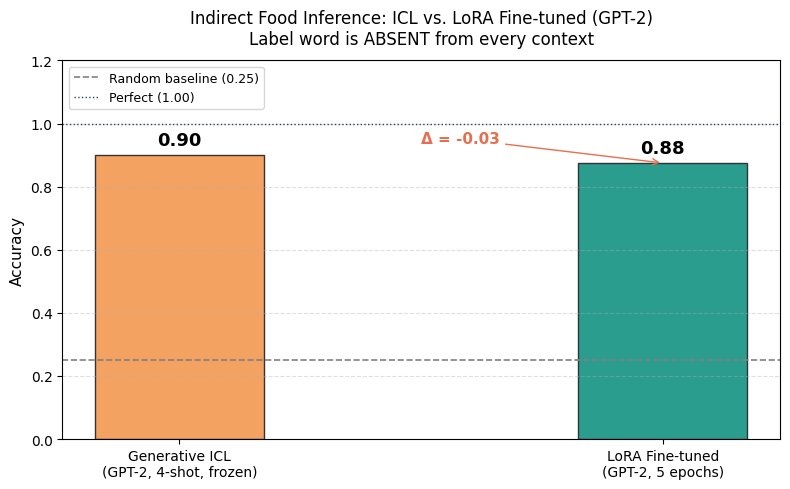

Plot saved to lora_vs_icl_indirect.png


In [ ]:
RANDOM_BASELINE = 1.0 / len(LABELS)    # 0.25 for 4 classes

print("=" * 52)
print(f"  Random baseline (4 classes)         : {RANDOM_BASELINE:.2f}")
print(f"  Generative ICL (GPT-2, {K_SHOT}-shot)      : {icl_acc:.2f}")
print(f"  LoRA Fine-tuned (GPT-2, 5 epochs)   : {lora_acc:.2f}")
print(f"  Accuracy gap (LoRA - ICL)            : {lora_acc - icl_acc:+.2f}")
print("=" * 52)

# ── Bar chart ─────────────────────────────────────────────────────────────────
method_labels = [
    f"Generative ICL\n(GPT-2, {K_SHOT}-shot, frozen)",
    "LoRA Fine-tuned\n(GPT-2, 5 epochs)",
]
values = [icl_acc, lora_acc]
colors = ["#f4a261", "#2a9d8f"]    # warm orange vs. teal for visual contrast

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(method_labels, values, color=colors, width=0.35, edgecolor="#333")

# Value labels on bars
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.2f}",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold",
    )

# Reference lines
ax.axhline(RANDOM_BASELINE, color="grey",   linestyle="--", lw=1.2,
           label=f"Random baseline ({RANDOM_BASELINE:.2f})")
ax.axhline(1.0,             color="#264653", linestyle=":",  lw=1.0,
           label="Perfect (1.00)")

# Annotate the gap between the two bars
gap = lora_acc - icl_acc
mid_x = 0.5   # midpoint between the two bars (indices 0 and 1)
ax.annotate(
    f"Δ = {gap:+.2f}",
    xy=(1, lora_acc), xytext=(0.5, (icl_acc + lora_acc) / 2 + 0.05),
    fontsize=11, color="#e76f51", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#e76f51"),
)

ax.set_title(
    "Indirect Food Inference: ICL vs. LoRA Fine-tuned (GPT-2)\n"
    "Label word is ABSENT from every context",
    fontsize=12, pad=12,
)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("lora_vs_icl_indirect.png", dpi=150)
plt.show()
print("Plot saved to lora_vs_icl_indirect.png")